# Adult Census Income Classification

## Imports

In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from category_encoders import BinaryEncoder
from imblearn.over_sampling import SMOTE

## Load Data

**Numerical attributes**

1. `age`: The age of an individual.
2. `fnlwgt` (final weight): The number of people the census estimates the entry represents.
3. `educational-num`: The highest level of education achieved in numerical form.
4. `capital-gain`: Capital gains for an individual.
5. `capital-loss`: Capital losses for an individual.
6. `hours-per-week`: The number of hours worked per week. 
---
**Categorical attributes**

7. `workclass`: The type of employment an individual has, such as Private, Self-emp-not-inc, Federal-gov, or Without-pay.
8. `education`: The highest level of education completed, such as Bachelors, HS-grad, or Masters.
9. `marital-status`: The individual's marital status, such as Married-civ-spouse or Never-married.
10. `occupation`: The general type of work performed, such as Tech-support, Craft-repair, or Exec-managerial.
11. relationship: The individual's role relative to others in their household, such as Wife, Own-child, or Not-in-family.
12. `race`: The individual's race, such as White, Black, or Asian-Pac-Islander.
13. `sex`: The biological sex of the individual, Male or Female.
14. `native-country`: The country of origin for the individual, with "United-States" being the most common category.
---
**Target variable**

16. `income`: This is a binary classification target indicating whether an individual's annual income is greater than $50,000 (>50K) or less than or equal to $50,000 (<=50K). 

In [89]:
df = pd.read_csv('Datasets\\adult.csv')
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


## EDA

### Exploring Numerical Features

In [91]:
numerical = df.select_dtypes(include='number').columns
numerical

Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

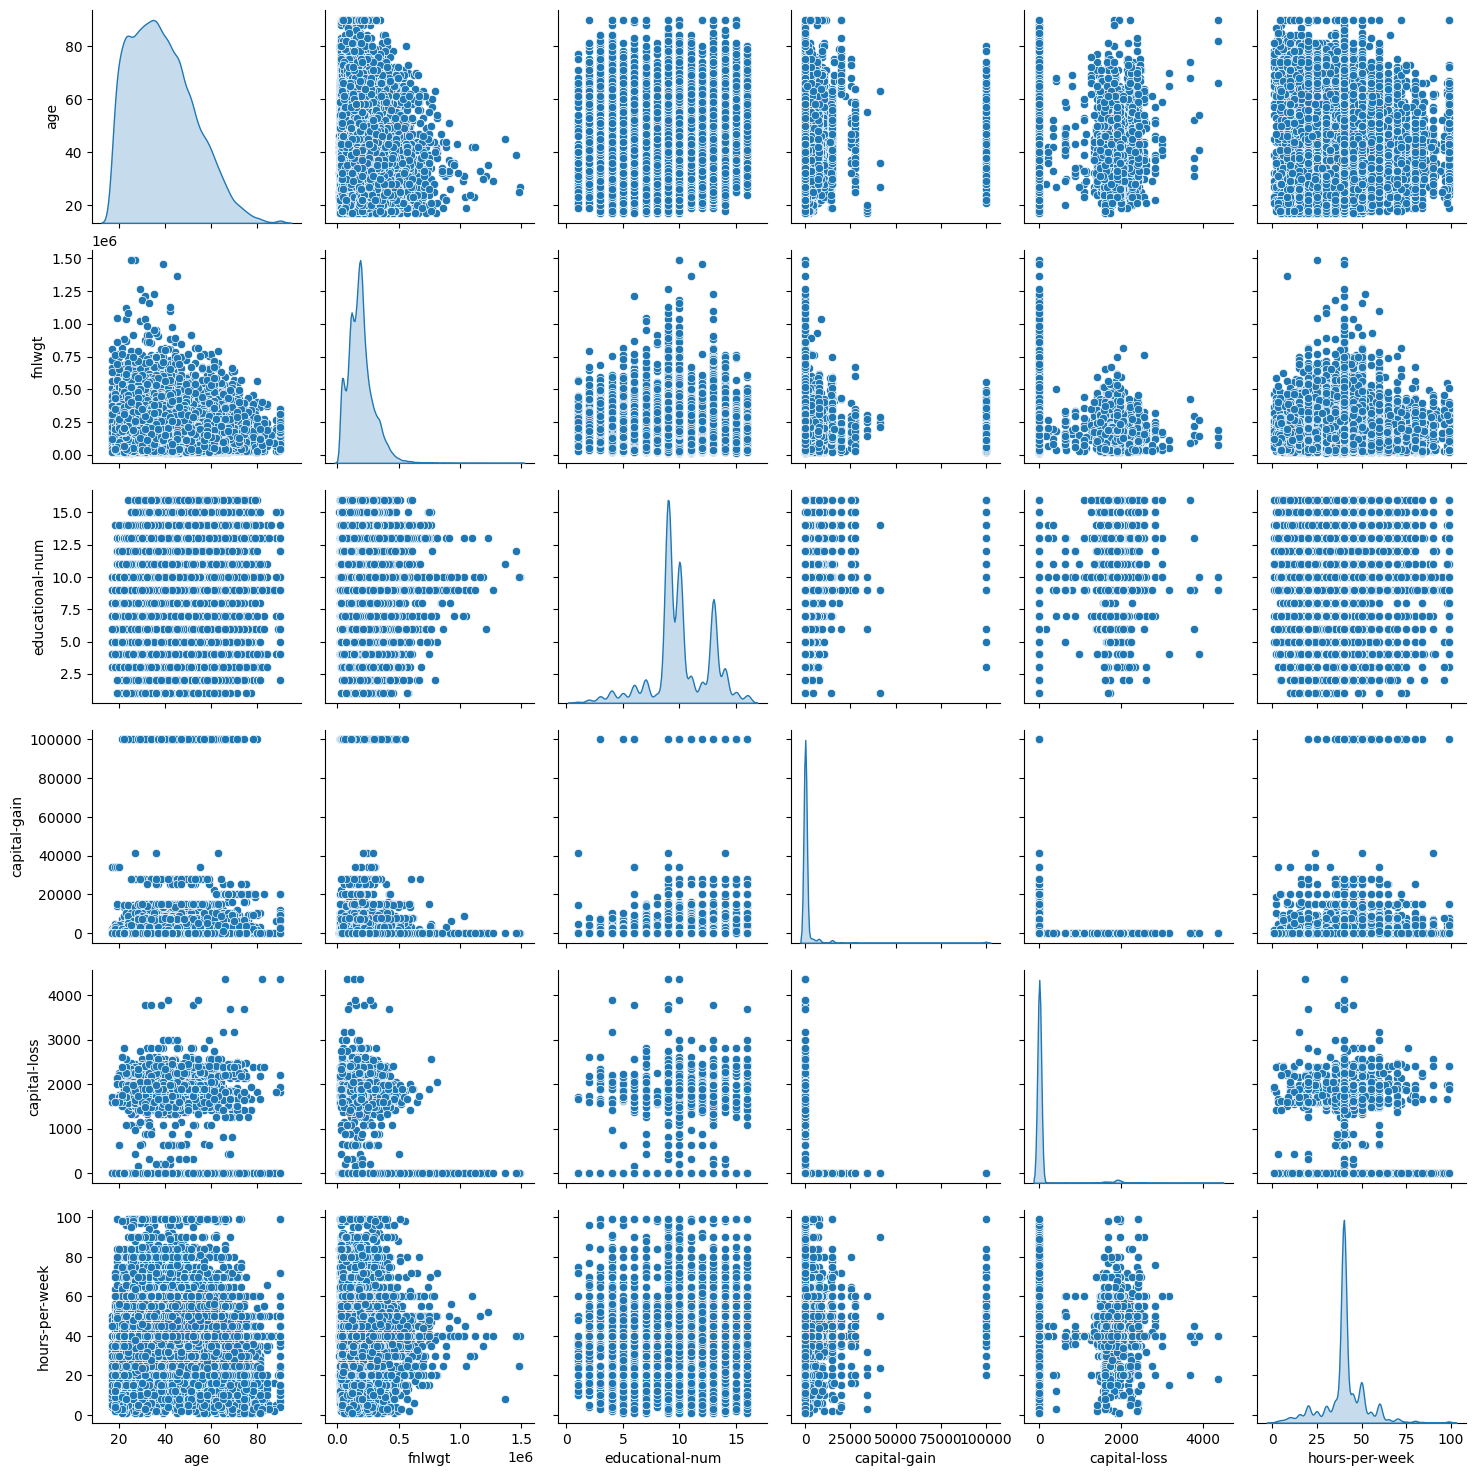

In [92]:
sns.pairplot(df[numerical], diag_kind='kde')
plt.show()

* age and fnlwgt are right skewed
* outliers in hours-per-week

In [93]:
sorted(df['educational-num'].value_counts().index)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

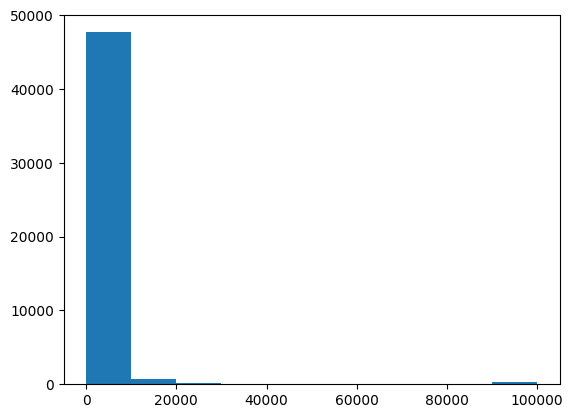

In [94]:
plt.hist(df['capital-gain'])
plt.show()

In [95]:
df['capital-gain'].value_counts(normalize=True)

capital-gain
0        0.917387
15024    0.010503
7688     0.008394
7298     0.007453
99999    0.004996
           ...   
6612     0.000020
1111     0.000020
22040    0.000020
1639     0.000020
2387     0.000020
Name: proportion, Length: 123, dtype: float64

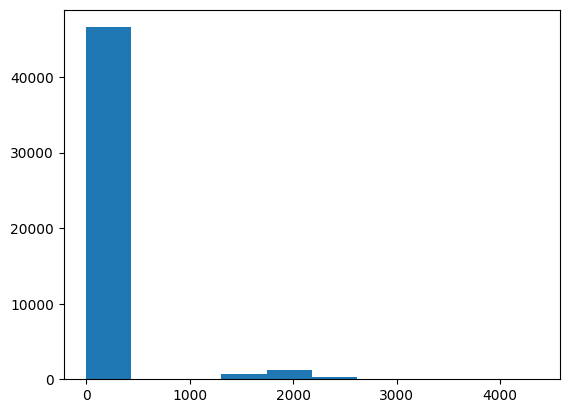

In [96]:
plt.hist(df['capital-loss'])
plt.show()

In [97]:
df['capital-loss'].value_counts(normalize=True)

capital-loss
0       0.953278
1902    0.006224
1977    0.005180
1887    0.004770
2415    0.001474
          ...   
1539    0.000020
2489    0.000020
2080    0.000020
155     0.000020
2201    0.000020
Name: proportion, Length: 99, dtype: float64

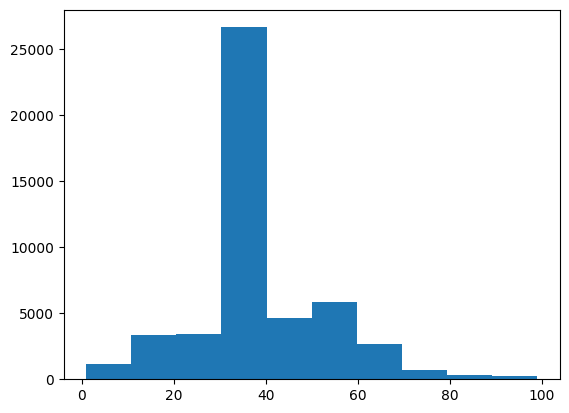

In [98]:
plt.hist(df['hours-per-week'])
plt.show()

In [99]:
df['hours-per-week'].value_counts(normalize=True)

hours-per-week
40    0.466873
50    0.086933
45    0.055628
60    0.044572
35    0.039658
        ...   
79    0.000020
94    0.000020
87    0.000020
69    0.000020
82    0.000020
Name: proportion, Length: 96, dtype: float64

**Conclusion**
1. `age` & `fnlwgt` Are skewed to the right.
2. `hours-per-week` Is nearly normally distributed.
3. `capital-gain` Contains approx. 92% zeroes.
4. `capital-loss` Contains approx. 95% zeroes.

### Exploring Categorical Features

In [100]:
categorical = df.select_dtypes(exclude='number').columns
categorical

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country', 'income'],
      dtype='object')

Exploring Value Counts For Each Feature

In [101]:
for col in categorical:
    display(df[col].value_counts())
    print("Number of values:", len(df[col].unique()))
    print(40 * '=')

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

Number of values: 9


education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

Number of values: 16


marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

...

Number of values: 2


native-country
United-States                 43832
Mexico                          951
?                               857
Philippines                     295
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy                           105
Dominican-Republic              103
Japan                            92
Guatemala                        88
Poland                           87
Vietnam                          86
Columbia                         85
Haiti                            75
Portugal                         67
Taiwan                           65
Iran                             59
Nicaragua                        49
Greece                           49
Peru         

Number of values: 42


income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Number of values: 2


**Conclusion**
1. `Work-class`, `occupation`, and `native-country`contain `?` that needs dealing with
2. `education` & `education-num` can be joined toghter to lessen features
3. `married` contains multiple married categories, that give same meaning, such as `married` & `married-af-spouse`, `separated` & `divorced`
4. `occupation` can be grouped by nature of work

## Pre-Processing

### Numerical

**Log Transformation** For `age` & `fnlwgt` to deal with skewness

In [102]:
df['age'] = np.log(df['age'])

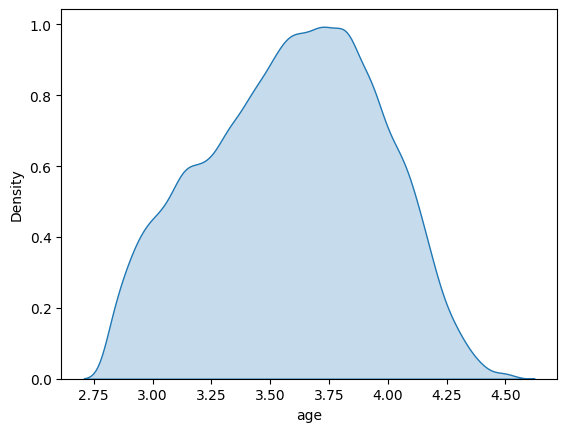

In [103]:
sns.kdeplot(data=df, x='age', fill=True)
plt.show()

In [104]:
df['fnlwgt'] = np.log(df['fnlwgt'])

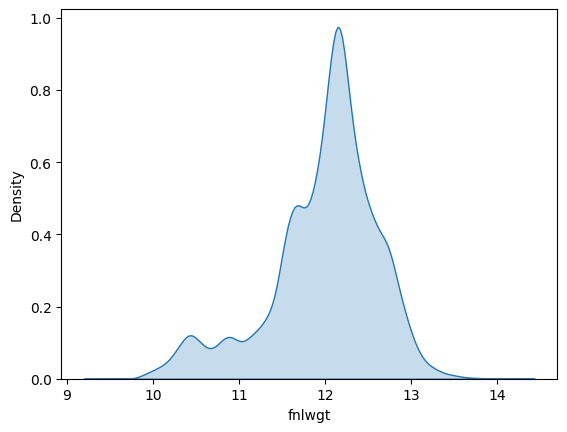

In [105]:
sns.kdeplot(data=df, x='fnlwgt', fill=True)
plt.show()

**Dropping** `capital-gain` & `capital-loss` as they are unrepresentitive (More than 90% 0's)

In [106]:
df.drop(['capital-gain', 'capital-loss'], axis=1, inplace=True)

### Categorical

**Dealing with `?`** \
`?` can be replaced with `other` as it means `unlisted` or `unkown`

In [107]:
mark_categories = ['workclass', 'occupation', 'native-country']
for col in mark_categories:
    df.loc[df[col] == '?', col] = 'other'

Grouping Countries By Continents

In [108]:
North_america=[
        "United-States",
        "Mexico",
        "Puerto-Rico",
        "Canada",
        "El-Salvador",
        "Cuba",
        "Jamaica",
        "Dominican-Republic",
        "Guatemala",
        "Nicaragua",
        "Haiti",
        "Honduras",
        "Trinadad&Tobago",
        "Outlying-US(Guam-USVI-etc)"
]

South_america=[
        "Columbia",
        "Peru",
        "Ecuador"
]
Europe=[
        "Germany",
        "England",
        "Italy",
        "Poland",
        "Portugal",
        "Greece",
        "France",
        "Ireland",
        "Yugoslavia",
        "Scotland",
        "Hungary"
    ]
    
Africa=[
        'South'
]

In [109]:
def continent_map(country):
    if country in Europe:
        return 'europe'
    elif country in North_america: 
        return 'north america'
    elif country in South_america: 
        return 'south america'
    elif country in Africa: 
        return 'south africa'
    elif country == 'other':
        return 'other'

df['continent'] = df['native-country'].map(continent_map)

In [110]:
df.drop('native-country', axis=1, inplace=True)

**Education**

Dropping `education`, as `education-num` is representitive enough

In [111]:
df[['educational-num', 'education']].value_counts().sort_index()

educational-num  education   
1                Preschool          83
2                1st-4th           247
3                5th-6th           509
4                7th-8th           955
5                9th               756
6                10th             1389
7                11th             1812
8                12th              657
9                HS-grad         15784
10               Some-college    10878
11               Assoc-voc        2061
12               Assoc-acdm       1601
13               Bachelors        8025
14               Masters          2657
15               Prof-school       834
16               Doctorate         594
Name: count, dtype: int64

In [112]:
df.drop('education', axis=1, inplace=True)

**marital-status**

* `married` -> `married-civ-spouse`, `married-spouse-absent`, `maried-af-spouse`
* `never-married` -> `never-married`
* `separated` -> `divorced`, `separated`
* `widowed` -> `widowed`

In [113]:
df['marital-status'].value_counts()

marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

In [114]:
married = ['Married-civ-spouse', 'Married-spouse-absent', 'Married-AF-spouse']
never_married = ['Never-married']
separated = ['Divorced', 'Separated']
widowed = ['Widowed']

def marital_status_map(x):
    if x in married:
        return 'Married'
    elif x in never_married:
        return 'Never-married'
    elif x in separated:
        return 'Separated'
    elif x in widowed:
        return 'Widowed'
    
df['marital-status'] = df['marital-status'].map(marital_status_map)

In [115]:
df['marital-status'].value_counts()

marital-status
Married          23044
Never-married    16117
Separated         8163
Widowed           1518
Name: count, dtype: int64

`occupation`

* Professional/Managerial:
    * Prof-specialty
    * Exec-managerial
    * Tech-support

* Clerical/Administrative:
    * Adm-clerical

* Sales/Service:
    * Sales
    * Other-service
    * Priv-house-serv
    * Protective-serv

* Skilled Trades/Manual:

    * Craft-repair
    * Machine-op-inspct
    * Transport-moving
    * Handlers-cleaners
    * Farming-fishing
* Military:

    * Armed-Forces

* Other/Unknown:
    * other

In [116]:
professional=['Prof-specialty', 'Exec-managerial', 'Tech-support']
clerical=['Adm-clerical']
sales=['Sales', 'Other-service', 'Priv-house-serv', 'Protective-serv']
skilled_trades=['Craft-repair', 'Machine-op-inspct', 'Transport-moving', 'Handlers-cleaners', 'Farming-fishing']
military=['Armed-Forces']
other=['other']

def occupation_map(x):
    if x in professional:
        return 'Professional'
    elif x in clerical:
        return 'Administrative'
    elif x in sales:
        return 'Sales'
    elif x in skilled_trades:
        return 'Skilled-Trades'
    elif x in military:
        return 'Military'
    else:
        return 'other'
    
df['occupation'] = df['occupation'].map(occupation_map)

In [117]:
df['occupation'].value_counts()

occupation
Skilled-Trades    15051
Professional      13704
Sales             11652
Administrative     5611
other              2809
Military             15
Name: count, dtype: int64

### Outliers

In [118]:
Q1 = df['hours-per-week'].quantile(0.25)
Q3 = df['hours-per-week'].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df['hours-per-week'] < (Q1 - 1.5 * IQR)) | (df['hours-per-week'] > (Q3 + 1.5 * IQR)))

outlier_ratio = outliers.sum() / df.shape[0]
print("Outlier Ratio: ", outlier_ratio)
print("Number of outliers: ", outliers.sum())

Outlier Ratio:  0.2763195610335367
Number of outliers:  13496


### Encoding

Label Encoding

In [119]:
df['is_male'] = df['gender'].replace({'Male': 1, 'Female' : 0})

C:\Users\shahe\AppData\Local\Temp\ipykernel_15184\3462198756.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['is_male'] = df['gender'].replace({'Male': 1, 'Female' : 0})


In [120]:
df.drop('gender', axis=1, inplace=True)

Binary Encoding

In [121]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'educational-num', 'marital-status',
       'occupation', 'relationship', 'race', 'hours-per-week', 'income',
       'continent', 'is_male'],
      dtype='object')

In [122]:
to_encode = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'continent']

encoder = BinaryEncoder(cols=to_encode)

df_encoded = encoder.fit_transform(df)

In [123]:
df_encoded.head()

,age,workclass_0,workclass_1,workclass_2,workclass_3,fnlwgt,educational-num,marital-status_0,marital-status_1,marital-status_2,...,relationship_2,race_0,race_1,race_2,hours-per-week,income,continent_0,continent_1,continent_2,is_male
0,3.218876,0,0,0,1,12.331833,7,0,0,1,...,1,0,0,1,40,<=50K,0,0,1,1
1,3.637586,0,0,0,1,11.405496,9,0,1,0,...,0,0,1,0,50,<=50K,0,0,1,1
2,3.332205,0,0,1,0,12.727693,12,0,1,0,...,0,0,1,0,40,>50K,0,0,1,1
3,3.784190,0,0,0,1,11.984946,10,0,1,0,...,0,0,0,1,40,>50K,0,0,1,1
4,2.890372,0,0,1,1,11.547298,10,0,0,1,...,1,0,1,0,30,<=50K,0,0,1,0


Train-Test Split

In [124]:
X = df_encoded.drop('income', axis=1)
y = df_encoded['income']

In [125]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [126]:
print("X_train Shape: ", X_train.shape)
print("X_test Shape: ", X_test.shape)
print("y_train Shape: ", y_train.shape)
print("y_test Shape: ", y_test.shape)


X_train Shape:  (39073, 24)
X_test Shape:  (9769, 24)
y_train Shape:  (39073,)
y_test Shape:  (9769,)


### Scaling

In [127]:
numerical = ['hours-per-week', 'fnlwgt']

In [128]:
scaler = preprocessing.MinMaxScaler()

X_train[numerical] = scaler.fit_transform(X_train[numerical])
X_test[numerical] = scaler.transform(X_test[numerical])

In [129]:
X_train

,age,workclass_0,workclass_1,workclass_2,workclass_3,fnlwgt,educational-num,marital-status_0,marital-status_1,marital-status_2,...,relationship_1,relationship_2,race_0,race_1,race_2,hours-per-week,continent_0,continent_1,continent_2,is_male
34342,4.262680,0,0,0,1,0.383496,9,0,0,1,...,1,1,0,1,0,0.163265,0,0,1,1
18559,2.833213,0,0,0,1,0.686201,6,0,0,1,...,1,0,0,1,0,0.091837,0,0,1,0
12477,3.295837,0,0,0,1,0.418242,9,0,1,0,...,1,0,0,1,0,0.397959,0,0,1,1
560,3.761200,0,0,0,1,0.484825,9,1,0,0,...,0,0,0,0,1,0.397959,0,0,1,0
3427,3.433987,0,0,0,1,0.504467,13,0,1,0,...,1,0,0,1,0,0.397959,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38073,3.496508,0,0,0,1,0.599349,9,0,1,0,...,1,0,0,1,0,0.602041,0,0,1,1
16306,4.025352,0,0,1,0,0.598764,13,0,1,0,...,1,0,0,1,0,0.397959,0,0,1,1
26860,3.583519,0,0,0,1,0.502418,10,0,1,0,...,1,0,0,1,0,0.397959,0,0,1,1
20602,3.465736,0,0,0,1,0.390935,9,0,1,0,...,1,0,0,1,0,0.397959,0,0,1,1


In [ ]:
y

0        <=50K
1        <=50K
2         >50K
3         >50K
4        <=50K
         ...  
48837    <=50K
48838     >50K
48839    <=50K
48840    <=50K
48841     >50K
Name: income, Length: 48842, dtype: object

In [134]:
y.value_counts(normalize=True)

income
<=50K    0.760718
>50K     0.239282
Name: proportion, dtype: float64

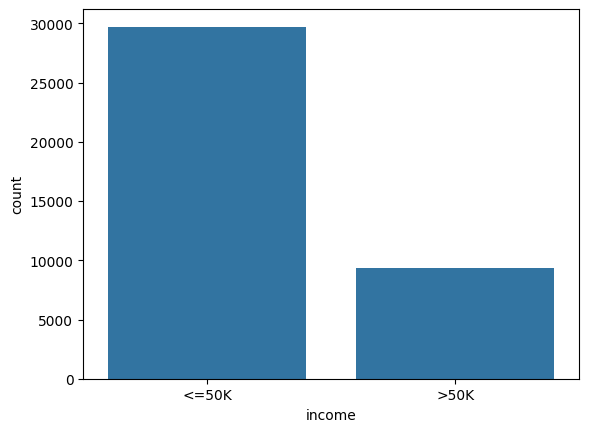

In [139]:
sns.countplot(x=y_train)
plt.show()

In [140]:
smote = SMOTE(sampling_strategy=0.7)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

income
<=50K    0.76073
>50K     0.23927
Name: proportion, dtype: float64

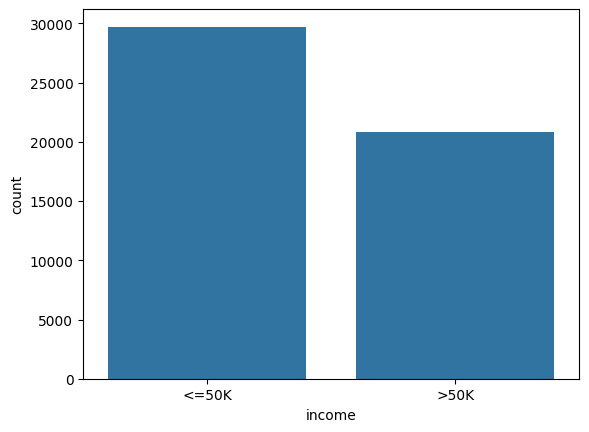

In [141]:
display(y_train.value_counts(normalize=True))
sns.countplot(x=y_train_resampled)
plt.show()